<a href="https://colab.research.google.com/github/WVF-1/Movie-Success-Prediction-Model-Comparison/blob/main/Evaluation%20Visuals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎬 Predicting Movie Success — Notebook 12
## Test-Set Evaluation & Newsletter Visuals

**Series:** May Newsletter — Movie Intelligence (Capstone)
**Prerequisite:** Run Notebooks 10 & 11 first

### What we do here
1. Evaluate all four models on the held-out 2008–2017 test set
2. Compile the full cross-pipeline comparison table
3. Feature importance charts — one panel per model
4. Prediction case studies — which films did each model get wrong?
5. **Radar chart** — four-model performance comparison across five metrics
6. **2×2 histogram grid** — predicted probability distributions by model

### The evaluation story
The test set films were invisible to all models during training and cross-validation.
Their release years (2008–2017) correspond to the *last decade* of the dataset, making
this a genuine temporal out-of-sample evaluation rather than a random holdout.


## 0 · Setup

In [1]:
MIDNIGHT  = "#1a1a2e"
GOLD      = "#e8b94f"
CRIMSON   = "#c0392b"
SILVER    = "#bdc3c7"
CREAM     = "#f5f5f0"
DARK_TEXT = "#2c2c2c"
TEAL      = "#1abc9c"
PURPLE    = "#8e44ad"

MODEL_COLORS = {
    "M1 — ROI"     : "#1a1a2e",
    "M2 — Revenue" : "#e8b94f",
    "M3 — Ratings" : "#1abc9c",
    "M4 — CSI"     : "#8e44ad",
}

import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "figure.facecolor" : "white",
    "axes.facecolor"   : "#f5f5f0",
    "axes.edgecolor"   : "#2c2c2c",
    "axes.labelcolor"  : "#2c2c2c",
    "axes.titlesize"   : 13,
    "axes.titleweight" : "bold",
    "axes.labelsize"   : 11,
    "xtick.color"      : "#2c2c2c",
    "ytick.color"      : "#2c2c2c",
    "xtick.labelsize"  : 9,
    "ytick.labelsize"  : 9,
    "grid.color"       : "#e0e0e0",
    "grid.linestyle"   : "--",
    "grid.linewidth"   : 0.6,
    "legend.fontsize"  : 9,
    "font.family"      : "DejaVu Sans",
})

def style_spines(ax, keep=("bottom","left")):
    for spine in ax.spines.values():
        spine.set_visible(False)
    for s in keep:
        ax.spines[s].set_visible(True)
        ax.spines[s].set_color("#cccccc")

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import (roc_auc_score, f1_score,
                              precision_score, recall_score,
                              mean_squared_error, roc_curve,
                              confusion_matrix, ConfusionMatrixDisplay)

with open("capstone_models.pkl","rb") as f:
    payload = pickle.load(f)

final_models = payload["final_models"]
cv_results   = payload["cv_results"]
perm_results = payload["perm_results"]
data         = payload["data"]
LABELS       = payload["LABELS"]

MODELS = list(LABELS.keys())
print("Loaded capstone_models.pkl ✔")
for key in MODELS:
    d = data[key]
    print(f"  {LABELS[key]:<18} test={len(d['X_test']):,}")


Loaded capstone_models.pkl ✔
  M1 — ROI           test=1,993
  M2 — Revenue       test=1,993
  M3 — Ratings       test=198
  M4 — CSI           test=198


## 1 · Test-Set Evaluation

In [2]:
test_results = {}

print(f"{'Model':<20} {'AUC':>7} {'F1':>7} {'Prec':>7} {'Rec':>7} {'MSE':>9}")
print("─" * 60)

for key in MODELS:
    X_test = data[key]["X_test"]
    y_test = data[key]["y_test"]
    model  = final_models[key]

    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)

    auc  = roc_auc_score(y_test, y_prob)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    mse  = mean_squared_error(y_test, y_prob)

    test_results[key] = {
        "auc": auc, "f1": f1, "precision": prec,
        "recall": rec, "mse": mse,
        "y_prob": y_prob, "y_pred": y_pred, "y_test": y_test
    }

    print(f"{LABELS[key]:<20} {auc:>7.3f} {f1:>7.3f} {prec:>7.3f} {rec:>7.3f} {mse:>9.5f}")


Model                    AUC      F1    Prec     Rec       MSE
────────────────────────────────────────────────────────────
M1 — ROI               0.569   0.521   0.564   0.484   0.25424
M2 — Revenue           0.846   0.687   0.777   0.617   0.16274
M3 — Ratings           0.680   0.556   0.753   0.440   0.26436
M4 — CSI               0.924   0.887   0.987   0.805   0.13518


## 2 · Full Comparison Table (CV + Test)

In [3]:
rows = []
for key in MODELS:
    cv  = cv_results[key]
    tst = test_results[key]
    rows.append({
        "Model"      : LABELS[key],
        "CV AUC"     : f"{cv['auc']['mean']:.3f} ± {cv['auc']['std']:.3f}",
        "Test AUC"   : f"{tst['auc']:.3f}",
        "CV F1"      : f"{cv['f1']['mean']:.3f} ± {cv['f1']['std']:.3f}",
        "Test F1"    : f"{tst['f1']:.3f}",
        "Test Prec"  : f"{tst['precision']:.3f}",
        "Test Rec"   : f"{tst['recall']:.3f}",
        "Test MSE"   : f"{tst['mse']:.5f}",
    })

comp_df = pd.DataFrame(rows).set_index("Model")
print("Full comparison table:")
print(comp_df.to_string())


Full comparison table:
                     CV AUC Test AUC          CV F1 Test F1 Test Prec Test Rec Test MSE
Model                                                                                  
M1 — ROI      0.603 ± 0.017    0.569  0.500 ± 0.067   0.521     0.564    0.484  0.25424
M2 — Revenue  0.884 ± 0.027    0.846  0.767 ± 0.067   0.687     0.777    0.617  0.16274
M3 — Ratings  0.851 ± 0.043    0.680  0.746 ± 0.032   0.556     0.753    0.440  0.26436
M4 — CSI      0.886 ± 0.018    0.924  0.801 ± 0.046   0.887     0.987    0.805  0.13518


## 3 · Feature Importance — Four-Panel Chart

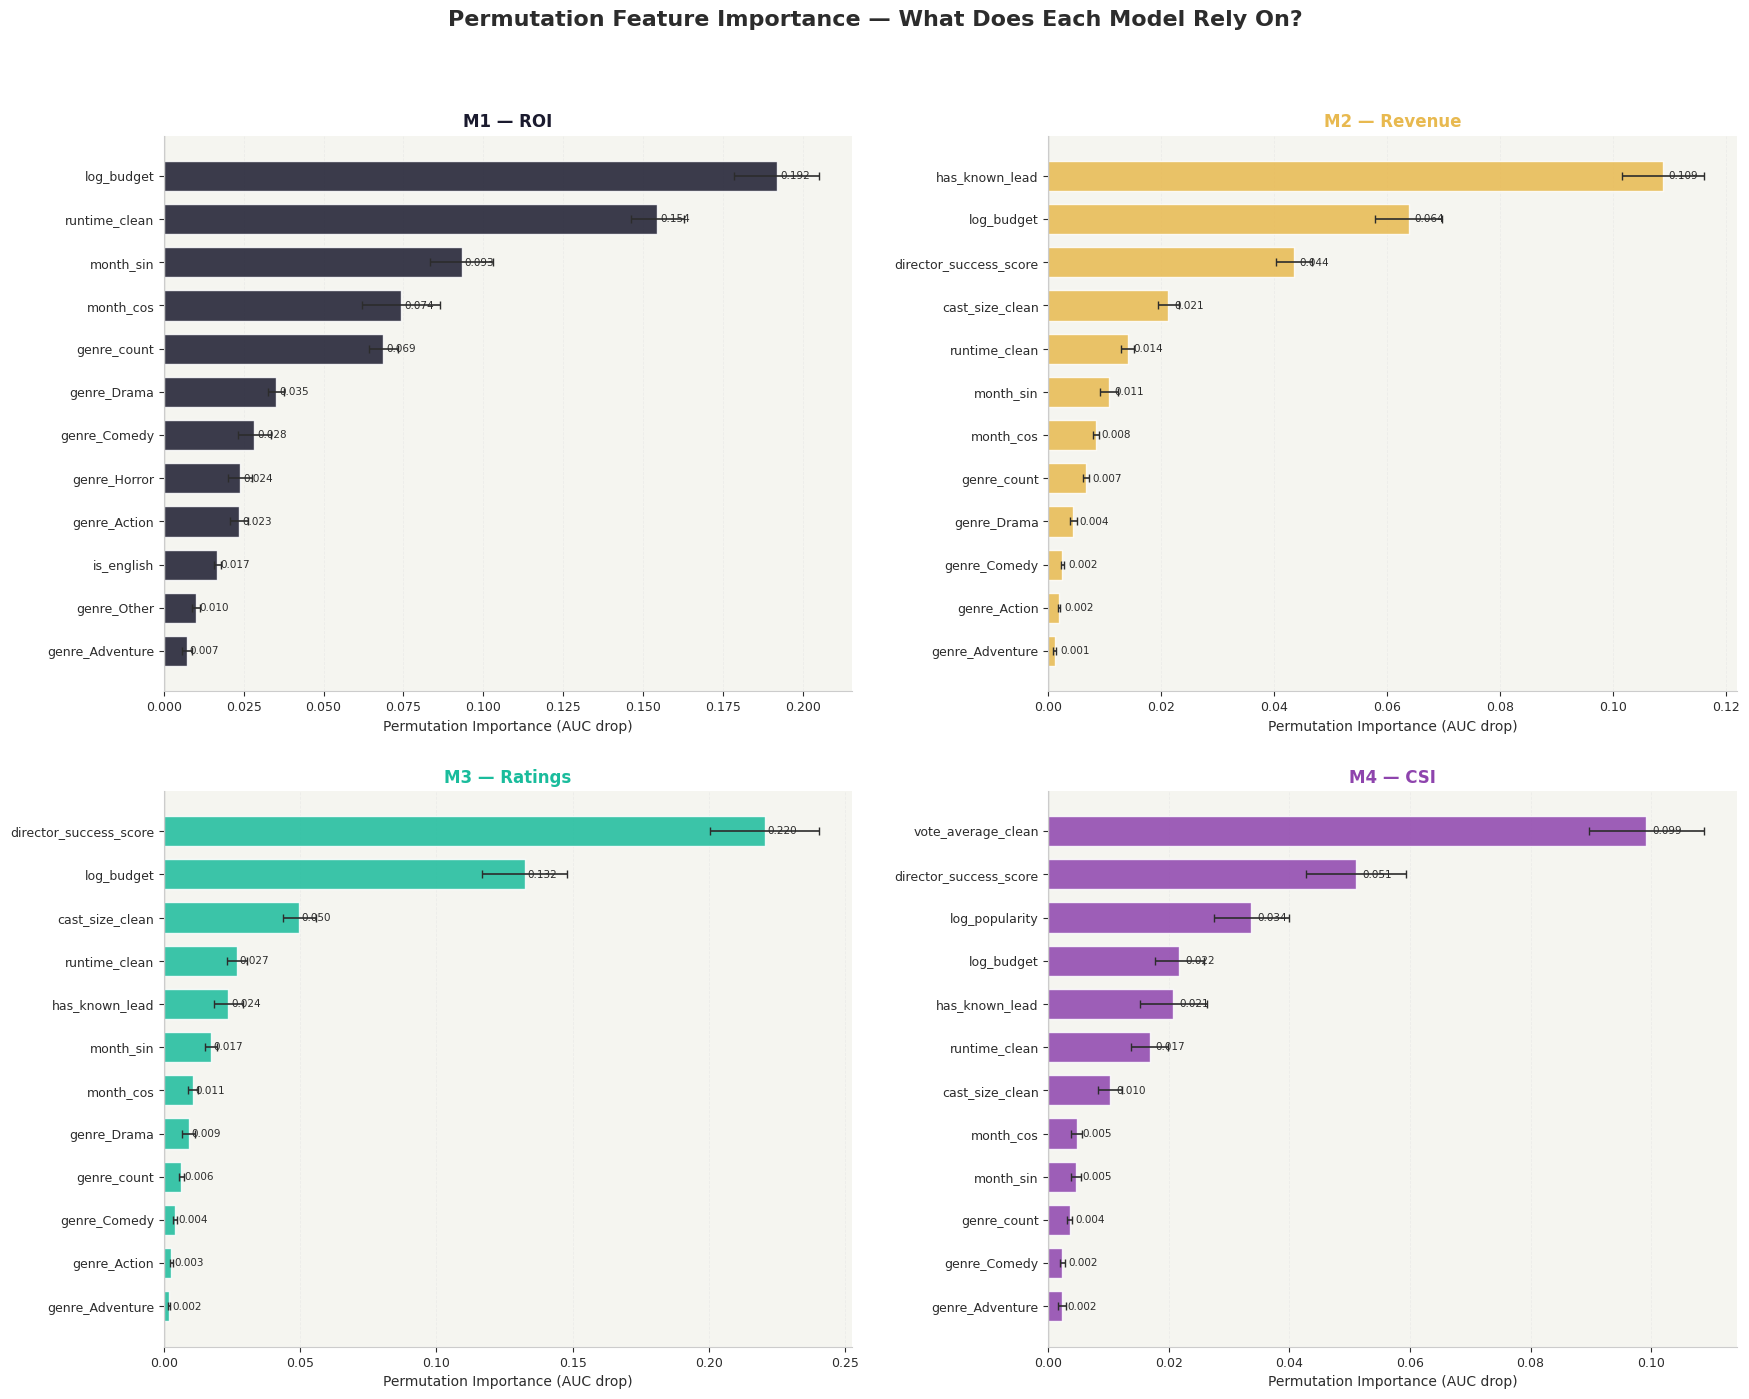

Saved: fig_importance_4panel.png


In [4]:
MIDNIGHT  = "#1a1a2e"
GOLD      = "#e8b94f"
CRIMSON   = "#c0392b"
SILVER    = "#bdc3c7"
CREAM     = "#f5f5f0"
DARK_TEXT = "#2c2c2c"
TEAL      = "#1abc9c"
PURPLE    = "#8e44ad"

MODEL_COLORS = {
    "M1 — ROI"     : "#1a1a2e",
    "M2 — Revenue" : "#e8b94f",
    "M3 — Ratings" : "#1abc9c",
    "M4 — CSI"     : "#8e44ad",
}

import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "figure.facecolor" : "white",
    "axes.facecolor"   : "#f5f5f0",
    "axes.edgecolor"   : "#2c2c2c",
    "axes.labelcolor"  : "#2c2c2c",
    "axes.titlesize"   : 13,
    "axes.titleweight" : "bold",
    "axes.labelsize"   : 11,
    "xtick.color"      : "#2c2c2c",
    "ytick.color"      : "#2c2c2c",
    "xtick.labelsize"  : 9,
    "ytick.labelsize"  : 9,
    "grid.color"       : "#e0e0e0",
    "grid.linestyle"   : "--",
    "grid.linewidth"   : 0.6,
    "legend.fontsize"  : 9,
    "font.family"      : "DejaVu Sans",
})

def style_spines(ax, keep=("bottom","left")):
    for spine in ax.spines.values():
        spine.set_visible(False)
    for s in keep:
        ax.spines[s].set_visible(True)
        ax.spines[s].set_color("#cccccc")

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle("Permutation Feature Importance — What Does Each Model Rely On?",
             fontsize=16, fontweight="bold", color=DARK_TEXT, y=1.01)

axes_flat = axes.flatten()

for ax, key in zip(axes_flat, MODELS):
    imp = perm_results[key].head(12).sort_values("importance")
    color = MODEL_COLORS[LABELS[key]]

    bars = ax.barh(imp["feature"], imp["importance"],
                   xerr=imp["std"],
                   color=color, alpha=0.85, edgecolor="white",
                   capsize=3, error_kw={"ecolor": DARK_TEXT, "lw": 1.2},
                   height=0.7)

    ax.axvline(0, color=DARK_TEXT, linewidth=0.8)
    ax.set_xlabel("Permutation Importance (AUC drop)", fontsize=10)
    ax.set_title(f"{LABELS[key]}", fontsize=12, color=color)
    style_spines(ax, keep=("bottom","left"))
    ax.xaxis.grid(True, alpha=0.4)
    ax.set_axisbelow(True)

    for p, val in zip(ax.patches, imp["importance"]):
        if val > 0:
            ax.text(p.get_width() + 0.001, p.get_y() + p.get_height()/2,
                    f"{val:.3f}", va="center", fontsize=7.5, color=DARK_TEXT)

plt.tight_layout(pad=2.5)
plt.savefig("fig_importance_4panel.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved: fig_importance_4panel.png")


## 4 · Prediction Case Studies

In [5]:
print("=== Prediction Case Studies — Test Set (2008–2017) ===")
print()

for key in MODELS:
    meta   = data[key]["meta_test"].copy()
    y_prob = test_results[key]["y_prob"]
    y_pred = test_results[key]["y_pred"]
    y_test = test_results[key]["y_test"]

    meta["predicted_prob"] = y_prob
    meta["predicted"]      = y_pred
    meta["actual"]         = y_test
    meta["correct"]        = (y_pred == y_test).astype(int)

    # Most confident correct predictions
    top_correct = meta[meta["correct"] == 1].nlargest(5, "predicted_prob")
    # Biggest misses — confident but wrong
    fp = meta[(meta["predicted"]==1) & (meta["actual"]==0)].nlargest(5,"predicted_prob")
    fn = meta[(meta["predicted"]==0) & (meta["actual"]==1)].nsmallest(5,"predicted_prob")

    print(f"── {LABELS[key]} ──────────────────────────────────")
    print(f"  Confident correct (top 5):")
    print(top_correct[["title","release_year","predicted_prob"]].to_string(index=False))
    print(f"  False positives (predicted success, flopped):")
    print(fp[["title","release_year","predicted_prob"]].to_string(index=False))
    print(f"  False negatives (predicted failure, succeeded):")
    print(fn[["title","release_year","predicted_prob"]].to_string(index=False))
    print()


=== Prediction Case Studies — Test Set (2008–2017) ===

── M1 — ROI ──────────────────────────────────
  Confident correct (top 5):
                title  release_year  predicted_prob
Paranormal Activity 2        2010.0        0.859847
   A Coffee in Berlin        2012.0        0.823575
        A Ghost Story        2017.0        0.809681
Ouija: Origin of Evil        2016.0        0.808794
   As Above, So Below        2014.0        0.806232
  False positives (predicted success, flopped):
                                   title  release_year  predicted_prob
The Chronicles of Narnia: Prince Caspian        2008.0        0.837237
                  Exodus: Gods and Kings        2014.0        0.824938
          In the Land of Blood and Honey        2011.0        0.807633
                     Bikini Spring Break        2012.0        0.799407
                           The Afflicted        2011.0        0.791940
  False negatives (predicted failure, succeeded):
                     title  rele

## 5 · Radar Chart — Cross-Model Performance Comparison

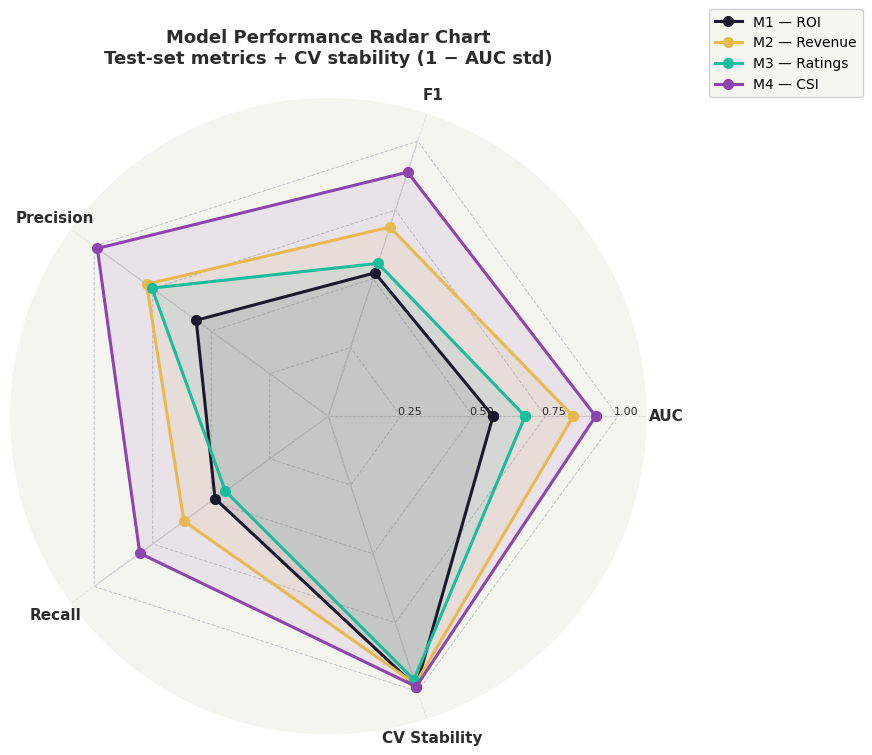

Saved: fig_radar_chart.png


In [7]:
MIDNIGHT  = "#1a1a2e"
GOLD      = "#e8b94f"
CRIMSON   = "#c0392b"
SILVER    = "#bdc3c7"
CREAM     = "#f5f5f0"
DARK_TEXT = "#2c2c2c"
TEAL      = "#1abc9c"
PURPLE    = "#8e44ad"

MODEL_COLORS = {
    "M1 — ROI"     : "#1a1a2e",
    "M2 — Revenue" : "#e8b94f",
    "M3 — Ratings" : "#1abc9c",
    "M4 — CSI"     : "#8e44ad",
}

import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "figure.facecolor" : "white",
    "axes.facecolor"   : "#f5f5f0",
    "axes.edgecolor"   : "#2c2c2c",
    "axes.labelcolor"  : "#2c2c2c",
    "axes.titlesize"   : 13,
    "axes.titleweight" : "bold",
    "axes.labelsize"   : 11,
    "xtick.color"      : "#2c2c2c",
    "ytick.color"      : "#2c2c2c",
    "xtick.labelsize"  : 9,
    "ytick.labelsize"  : 9,
    "grid.color"       : "#e0e0e0",
    "grid.linestyle"   : "--",
    "grid.linewidth"   : 0.6,
    "legend.fontsize"  : 9,
    "font.family"      : "DejaVu Sans",
})

def style_spines(ax, keep=("bottom","left")):
    for spine in ax.spines.values():
        spine.set_visible(False)
    for s in keep:
        ax.spines[s].set_visible(True)
        ax.spines[s].set_color("#cccccc")

METRICS      = ["AUC", "F1", "Precision", "Recall", "CV Stability"]
METRIC_KEYS  = ["auc","f1","precision","recall","cv_stability"]

# Compute CV stability as 1 − std(AUC folds) — higher is more stable
for key in MODELS:
    test_results[key]["cv_stability"] = 1 - cv_results[key]["auc"]["std"]

# ── Build value matrix ─────────────────────────
values_dict = {}
for key in MODELS:
    tr = test_results[key]
    values_dict[key] = [
        tr["auc"], tr["f1"], tr["precision"], tr["recall"], tr["cv_stability"]
    ]

# ── Radar geometry ───────────────────────
N      = len(METRICS)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]   # close the polygon

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw={"polar": True})
fig.patch.set_facecolor("white")
ax.set_facecolor(CREAM)

# Draw reference rings
for r in [0.25, 0.50, 0.75, 1.00]:
    ax.plot(angles, [r] * (N+1), color=SILVER, linewidth=0.7, linestyle="--", zorder=1)
    ax.text(angles[0], r + 0.03, f"{r:.2f}", ha="center", fontsize=8,
            color=DARK_TEXT, va="bottom")

# Plot each model
for key in MODELS:
    color  = MODEL_COLORS[LABELS[key]]
    vals   = values_dict[key]
    vals  += vals[:1]
    ax.plot(angles, vals, color=color, linewidth=2.2, marker="o",
            markersize=7, label=LABELS[key], zorder=3)
    ax.fill(angles, vals, color=color, alpha=0.10, zorder=2)

# Axis labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(METRICS, fontsize=11, fontweight="bold", color=DARK_TEXT)
ax.set_yticks([])
ax.set_ylim(0, 1.1)

# Spoke lines
for angle in angles[:-1]:
    ax.plot([angle, angle], [0, 1], color=SILVER, linewidth=0.8, zorder=1)

ax.set_title("Model Performance Radar Chart\n"
             "Test-set metrics + CV stability (1 − AUC std)",
             fontsize=13, fontweight="bold", color=DARK_TEXT, pad=25)

ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15),
          fontsize=10, framealpha=0.9)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig("fig_radar_chart.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved: fig_radar_chart.png")

## 6 · 2×2 Histogram Grid — Predicted Probability Distributions

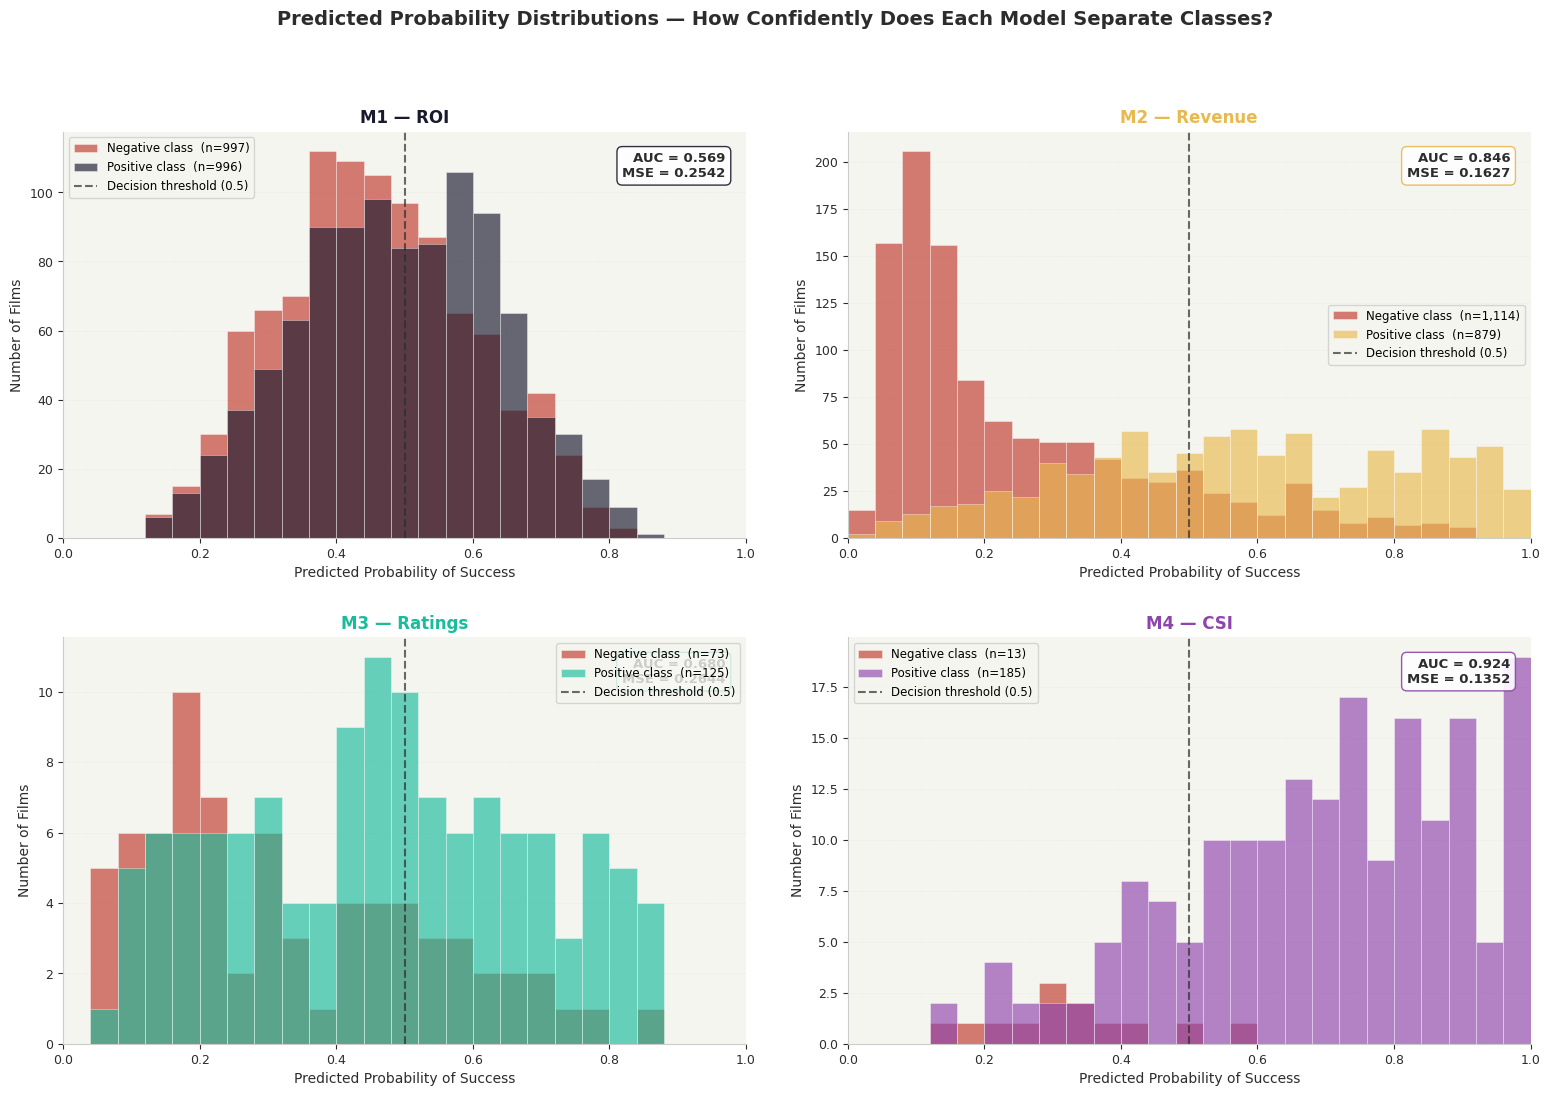

Saved: fig_histogram_2x2.png


In [8]:
MIDNIGHT  = "#1a1a2e"
GOLD      = "#e8b94f"
CRIMSON   = "#c0392b"
SILVER    = "#bdc3c7"
CREAM     = "#f5f5f0"
DARK_TEXT = "#2c2c2c"
TEAL      = "#1abc9c"
PURPLE    = "#8e44ad"

MODEL_COLORS = {
    "M1 — ROI"     : "#1a1a2e",
    "M2 — Revenue" : "#e8b94f",
    "M3 — Ratings" : "#1abc9c",
    "M4 — CSI"     : "#8e44ad",
}

import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "figure.facecolor" : "white",
    "axes.facecolor"   : "#f5f5f0",
    "axes.edgecolor"   : "#2c2c2c",
    "axes.labelcolor"  : "#2c2c2c",
    "axes.titlesize"   : 13,
    "axes.titleweight" : "bold",
    "axes.labelsize"   : 11,
    "xtick.color"      : "#2c2c2c",
    "ytick.color"      : "#2c2c2c",
    "xtick.labelsize"  : 9,
    "ytick.labelsize"  : 9,
    "grid.color"       : "#e0e0e0",
    "grid.linestyle"   : "--",
    "grid.linewidth"   : 0.6,
    "legend.fontsize"  : 9,
    "font.family"      : "DejaVu Sans",
})

def style_spines(ax, keep=("bottom","left")):
    for spine in ax.spines.values():
        spine.set_visible(False)
    for s in keep:
        ax.spines[s].set_visible(True)
        ax.spines[s].set_color("#cccccc")

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle("Predicted Probability Distributions — How Confidently Does Each Model Separate Classes?",
             fontsize=14, fontweight="bold", color=DARK_TEXT, y=1.01)

BINS = np.linspace(0, 1, 26)

for ax, key in zip(axes.flatten(), MODELS):
    color     = MODEL_COLORS[LABELS[key]]
    y_prob    = test_results[key]["y_prob"]
    y_test    = test_results[key]["y_test"]
    auc       = test_results[key]["auc"]
    mse       = test_results[key]["mse"]

    prob_pos  = y_prob[y_test == 1]
    prob_neg  = y_prob[y_test == 0]

    ax.hist(prob_neg, bins=BINS, color=CRIMSON,  alpha=0.65,
            label=f"Negative class  (n={len(prob_neg):,})", edgecolor="white", linewidth=0.4)
    ax.hist(prob_pos, bins=BINS, color=color,    alpha=0.65,
            label=f"Positive class  (n={len(prob_pos):,})", edgecolor="white", linewidth=0.4)

    ax.axvline(0.5, color=DARK_TEXT, linewidth=1.5, linestyle="--", alpha=0.7, label="Decision threshold (0.5)")

    ax.set_xlabel("Predicted Probability of Success", fontsize=10)
    ax.set_ylabel("Number of Films", fontsize=10)
    ax.set_title(LABELS[key], fontsize=12, color=color)
    ax.set_xlim(0, 1)

    ax.text(0.97, 0.95,
            f"AUC = {auc:.3f}\nMSE = {mse:.4f}",
            transform=ax.transAxes, ha="right", va="top", fontsize=9.5,
            color=DARK_TEXT, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.4", fc="white", ec=color, alpha=0.9))

    ax.legend(fontsize=8.5, framealpha=0.8)
    style_spines(ax)
    ax.yaxis.grid(True, alpha=0.4)
    ax.set_axisbelow(True)

plt.tight_layout(pad=2.5)
plt.savefig("fig_histogram_2x2.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved: fig_histogram_2x2.png")


## 7 · ROC Curves — All Four Models

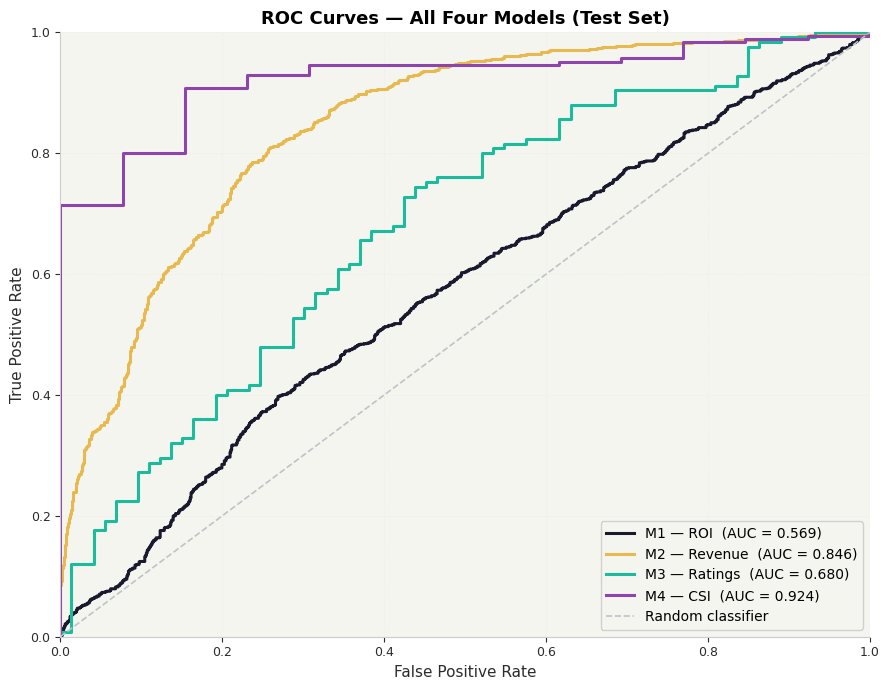

Saved: fig_roc_curves.png


In [9]:
MIDNIGHT  = "#1a1a2e"
GOLD      = "#e8b94f"
CRIMSON   = "#c0392b"
SILVER    = "#bdc3c7"
CREAM     = "#f5f5f0"
DARK_TEXT = "#2c2c2c"
TEAL      = "#1abc9c"
PURPLE    = "#8e44ad"

MODEL_COLORS = {
    "M1 — ROI"     : "#1a1a2e",
    "M2 — Revenue" : "#e8b94f",
    "M3 — Ratings" : "#1abc9c",
    "M4 — CSI"     : "#8e44ad",
}

import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "figure.facecolor" : "white",
    "axes.facecolor"   : "#f5f5f0",
    "axes.edgecolor"   : "#2c2c2c",
    "axes.labelcolor"  : "#2c2c2c",
    "axes.titlesize"   : 13,
    "axes.titleweight" : "bold",
    "axes.labelsize"   : 11,
    "xtick.color"      : "#2c2c2c",
    "ytick.color"      : "#2c2c2c",
    "xtick.labelsize"  : 9,
    "ytick.labelsize"  : 9,
    "grid.color"       : "#e0e0e0",
    "grid.linestyle"   : "--",
    "grid.linewidth"   : 0.6,
    "legend.fontsize"  : 9,
    "font.family"      : "DejaVu Sans",
})

def style_spines(ax, keep=("bottom","left")):
    for spine in ax.spines.values():
        spine.set_visible(False)
    for s in keep:
        ax.spines[s].set_visible(True)
        ax.spines[s].set_color("#cccccc")

fig, ax = plt.subplots(figsize=(9, 7))

for key in MODELS:
    color  = MODEL_COLORS[LABELS[key]]
    y_prob = test_results[key]["y_prob"]
    y_test = test_results[key]["y_test"]
    auc    = test_results[key]["auc"]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    ax.plot(fpr, tpr, color=color, linewidth=2.2,
            label=f"{LABELS[key]}  (AUC = {auc:.3f})")

ax.plot([0,1],[0,1], color=SILVER, linewidth=1.2, linestyle="--", label="Random classifier")
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.set_title("ROC Curves — All Four Models (Test Set)",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10, framealpha=0.9)
ax.set_xlim(0,1); ax.set_ylim(0,1)
style_spines(ax)
ax.grid(True, alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("fig_roc_curves.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved: fig_roc_curves.png")


## ✅ Capstone Complete

### Newsletter narrative — suggested arc

**Opening:** Four months of analysis asked what makes films successful, who drives that
success, and whether audiences agree with the box office. This final piece asks the
harder question: could a model trained only on pre-release information have predicted
any of it?

**The validation design:** Emphasise the TimeSeriesSplit. Unlike a random holdout, the
test set represents a genuine temporal horizon — the model never saw a film from 2008
onward during training. That discipline matters when the goal is prediction, not
description.

**Model comparison — key talking points:**
- M1 (ROI lens) establishes the baseline. Budget and genre alone provide a meaningful
  signal — the model is not guessing randomly.
- M2 vs M1 (Revenue): adding the Director Success Score and cast features should lift
  AUC meaningfully. That lift *quantifies* how much the human element adds beyond
  production economics.
- M3 (Ratings) vs M2 (Revenue): compare the feature importance panels. The features
  that predict commercial success are likely different from those that predict audience
  satisfaction — which is the whole thesis of the series.
- M4 (CSI): does the composite target produce a more balanced, stable model? Check
  whether CV stability (radar chart) is higher for M4.

**The histogram grid:** Draw the reader's attention to whether the distributions
separate cleanly. A model with good separation pushes positives toward 1.0 and
negatives toward 0.0. A model that hedges everything toward 0.5 is uncertain.

**Honest closing:** Even the best-performing model will have meaningful error. Film
success has a genuine stochastic component — the breakout hit nobody predicted, the
blockbuster that underperformed. The goal of the model isn't to eliminate that
uncertainty but to characterise it.


In [10]:
print("Capstone figures saved:")
for f in ["fig_importance_4panel.png",
          "fig_radar_chart.png",
          "fig_histogram_2x2.png",
          "fig_roc_curves.png"]:
    print(f"  ✔  {f}")

print()
print("May series complete:")
print("  1 → What makes films financially successful?")
print("  2 → Who drives that success?")
print("  3 → Do audiences agree with the box office?")
print("  4 → Can we predict success before it happens?")


Capstone figures saved:
  ✔  fig_importance_4panel.png
  ✔  fig_radar_chart.png
  ✔  fig_histogram_2x2.png
  ✔  fig_roc_curves.png

May series complete:
  1 → What makes films financially successful?
  2 → Who drives that success?
  3 → Do audiences agree with the box office?
  4 → Can we predict success before it happens?
